In [3]:
import pandas as pd

In [43]:
import matplotlib.pyplot as plt

In [5]:
#Import processed data
df=pd.read_csv("C:/Users/USER/Downloads/final_sales_data.csv")


In [7]:
#Sort data by date
df= df.sort_values('date')

In [9]:
cutoff_date = '2024-01-01'

train = df[df['date'] < cutoff_date]
test = df[df['date'] >= cutoff_date]

In [11]:
#Orders summed per month to give rise to meaningful prediction of future orders since ARIMA is a univariate model designed to forecast a single time series

df['date'] = pd.to_datetime(df['date'])

monthly_orders = (
    df
    .groupby(pd.Grouper(key='date', freq='MS'))['orders']
    .sum()
    .reset_index()
)

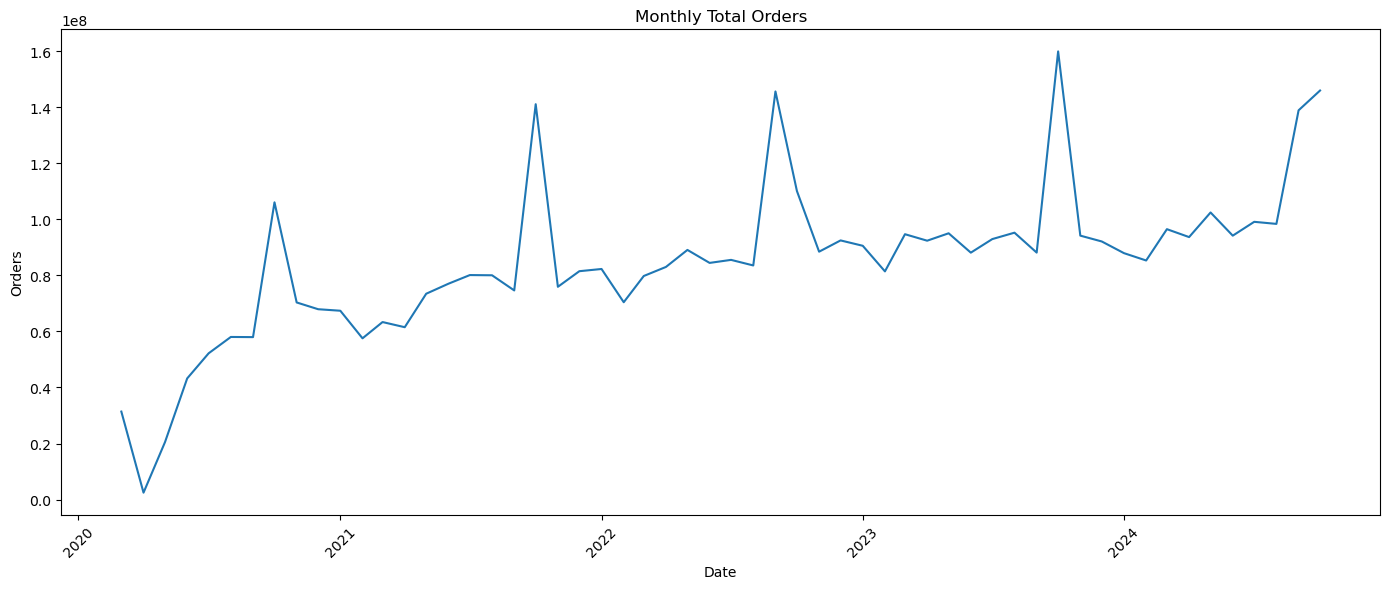

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders['date'],
    monthly_orders['orders']
)

plt.title('Monthly Total Orders')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

# Select training data only
monthly_train = monthly_orders[
    monthly_orders['date'] < '2024-01-01'
].copy()

# Perform ADF test on training orders
result = adfuller(monthly_train['orders'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -3.814611785492825
p-value: 0.002761305868612251

Critical Values:
1%: -3.584828853223594
5%: -2.9282991495198907
10%: -2.6023438271604937


In [15]:
# Making sure monthly data is sorted
monthly_orders = monthly_orders.sort_values('date').reset_index(drop=True)

# Original train/test split
cutoff_date = '2024-01-01'

monthly_train = monthly_orders[
    monthly_orders['date'] < cutoff_date
].copy()

monthly_test = monthly_orders[
    monthly_orders['date'] >= cutoff_date
].copy()

# Validation split
validation_size = 10

model_train = monthly_train.iloc[:-validation_size]
validation = monthly_train.iloc[-validation_size:]

# Extract ONLY orders for ARIMA
y_model_train = model_train['orders']
y_validation = validation['orders']
y_test = monthly_test['orders']

print("Model training observations:", len(y_model_train))
print("Validation observations:", len(y_validation))
print("Final test observations:", len(y_test))

Model training observations: 36
Validation observations: 10
Final test observations: 10


In [25]:
import warnings
warnings.filterwarnings("ignore")

In [27]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

results = []

for p in range(0, 6):
    for q in range(0, 6):

        try:
            # Fit ARIMA on model-training data
            model = ARIMA(
                y_model_train,
                order=(p, 0, q)
            )

            model_fit = model.fit()

            # Forecast validation period
            forecast = model_fit.forecast(
                steps=len(y_validation)
            )

            # Validation RMSE
            rmse = np.sqrt(
                mean_squared_error(
                    y_validation,
                    forecast
                )
            )

            results.append({
                'p': p,
                'd': 0,
                'q': q,
                'AIC': model_fit.aic,
                'BIC': model_fit.bic,
                'Validation_RMSE': rmse
            })

        except Exception as e:
            print(f"ARIMA({p},0,{q}) failed: {e}")

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'Validation_RMSE'
)



In [ ]:
#Hyperparameter Tuning for ARIMA

In [33]:
results_df.sort_values('AIC').head(10)

,p,d,q,AIC,BIC,Validation_RMSE
14,2,0,2,1324.508919,1334.010033,3.564255e+07
6,1,0,0,1324.806931,1329.557487,3.095435e+07
7,1,0,1,1325.149179,1331.483255,2.815074e+07
12,2,0,0,1325.588266,1331.922342,2.981119e+07
20,3,0,2,1325.980438,1337.065070,3.499728e+07
18,3,0,0,1327.049404,1334.966999,2.852358e+07
13,2,0,1,1327.100456,1335.018051,2.850346e+07
8,1,0,2,1327.136734,1335.054328,2.881798e+07
5,0,0,5,1327.528943,1338.613576,3.402707e+07
21,3,0,3,1327.741990,1340.410141,3.554603e+07


In [35]:
results_df.sort_values('BIC').head(10)

,p,d,q,AIC,BIC,Validation_RMSE
6,1,0,0,1324.806931,1329.557487,3.095435e+07
7,1,0,1,1325.149179,1331.483255,2.815074e+07
12,2,0,0,1325.588266,1331.922342,2.981119e+07
14,2,0,2,1324.508919,1334.010033,3.564255e+07
18,3,0,0,1327.049404,1334.966999,2.852358e+07
13,2,0,1,1327.100456,1335.018051,2.850346e+07
8,1,0,2,1327.136734,1335.054328,2.881798e+07
1,0,0,1,1330.964043,1335.714600,3.142562e+07
2,0,0,2,1330.030634,1336.364710,3.147194e+07
3,0,0,3,1328.980756,1336.898350,3.081564e+07


In [37]:
results_df.sort_values('Validation_RMSE').head(10)

,p,d,q,AIC,BIC,Validation_RMSE
7,1,0,1,1325.149179,1331.483255,2.815074e+07
13,2,0,1,1327.100456,1335.018051,2.850346e+07
18,3,0,0,1327.049404,1334.966999,2.852358e+07
26,4,0,2,1331.707504,1344.375656,2.862406e+07
25,4,0,1,1329.600999,1340.685632,2.871637e+07
19,3,0,1,1328.799764,1338.300878,2.875357e+07
8,1,0,2,1327.136734,1335.054328,2.881798e+07
24,4,0,0,1328.796527,1338.297640,2.882379e+07
15,2,0,3,1329.390584,1340.475217,2.921593e+07
30,5,0,0,1330.554512,1341.639144,2.944328e+07


In [ ]:
#(1,0,1) is chosen as best p,d,q combination for this model, based on lowest Validation_rmse and sufficiently low AIC,BIC Values

In [55]:
# Combine model-training and validation data
y_final_train = pd.concat([
    y_model_train,
    y_validation
])

# Fit final ARIMA using the selected p,d,q
final_model = ARIMA(
    y_final_train,
    order=(1, 0, 1)
)

final_model_fit = final_model.fit()

# Forecast the test period
test_forecast = final_model_fit.forecast(
    steps=len(y_test)
)

# Calculate final test RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

final_rmse = np.sqrt(
    mean_squared_error(y_test, test_forecast)
)

print("Final Test RMSE:", final_rmse)

Final Test RMSE: 23386667.46692034


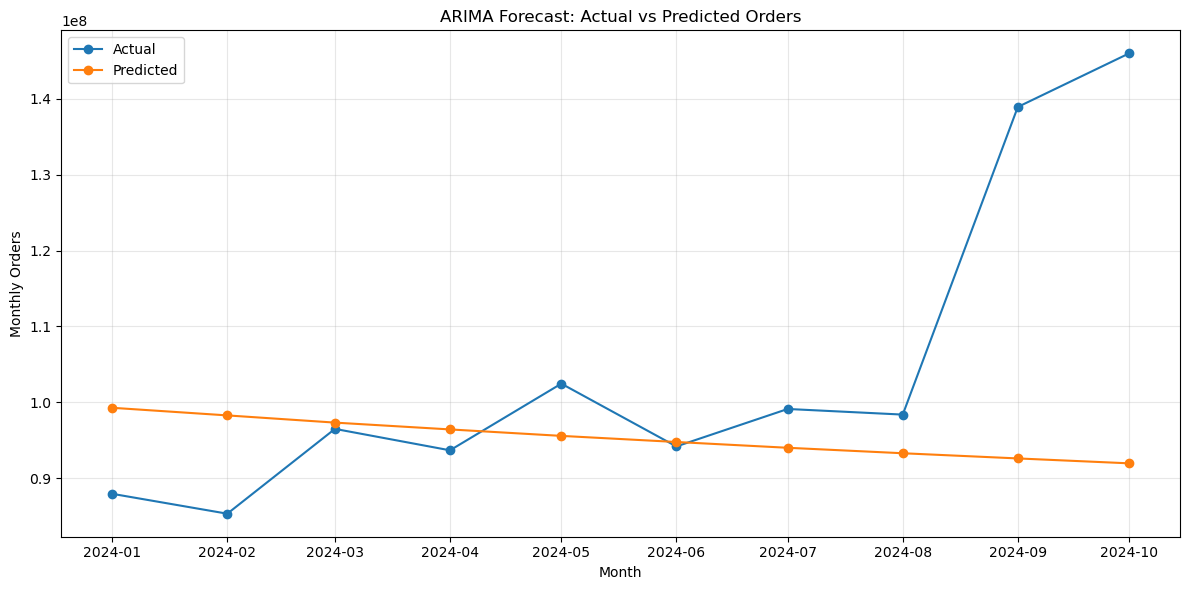

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_test['date'], y_test,
         label='Actual', marker='o')

plt.plot(monthly_test['date'], test_forecast,
         label='Predicted', marker='o')

plt.title('ARIMA Forecast: Actual vs Predicted Orders')
plt.xlabel('Month')
plt.ylabel('Monthly Orders')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_test,test_forecast)
)
arirmse=round(rmse,2)
# MAE
mae = mean_absolute_error(
    y_test,test_forecast
)
arimae=round(mae,2)
# R-squared
r2 = r2_score(
    y_test, test_forecast
)
arir2=round(r2,2)
# MAPE
mape = np.mean(
    np.abs((y_test -test_forecast) / y_test)
) * 100
arimape=round(mape,2)
# SMAPE
smape = np.mean(
    2 * np.abs(y_test -test_forecast) /
    (np.abs(y_test) + np.abs(test_forecast))
) * 100
arismape=round(smape,2)
# Print results
print("RMSE :", arirmse)
print("MAE  :", arimae)
print("R²   :", arir2)
print("MAPE :", arimape, "%")
print("SMAPE:", arismape, "%")

RMSE : 23386667.47
MAE  : 14590219.89
R²   : -0.4
MAPE : 11.99 %
SMAPE: 13.36 %


In [ ]:
# These results cannot be compared with those of LSTM,XGBOOST, RANDOM FOREST AND LINEAR REGRESSION 
# ARIMA was explored using monthly aggregated demand
# The other ML Models were trained using granular features and  date-wise records

In [ ]:
###########################################################################################################################

In [9]:
#DIRECT MODEL TRAINING WITHOUT MONTH BASED SUMMING-CELL RUNS INDEFINITELY
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# Use the existing train and test data
y_train = train['orders']
y_test = test['orders']

# Store results for different p and q combinations
results = []

# d = 0 because the orders series was found to be stationary
for p in range(0, 6):
    for q in range(0, 6):

        try:
            # Build ARIMA(p, 0, q)
            model = ARIMA(y_train, order=(p, 0, q))

            # Fit the model
            model_fit = model.fit()

            # Forecast the test period
            y_pred = model_fit.forecast(steps=len(y_test))

            # Calculate RMSE
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            # Store results
            results.append({
                'p': p,
                'd': 0,
                'q': q,
                'AIC': model_fit.aic,
                'BIC': model_fit.bic,
                'RMSE': rmse
            })

        except Exception as e:
            continue

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display models with lowest RMSE
results_df.sort_values('RMSE').head(10)


KeyboardInterrupt

